<a href="https://colab.research.google.com/github/Herm1oneJeanGranger/acratie/blob/resume-project/hw_1_game_of_thrones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2024</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

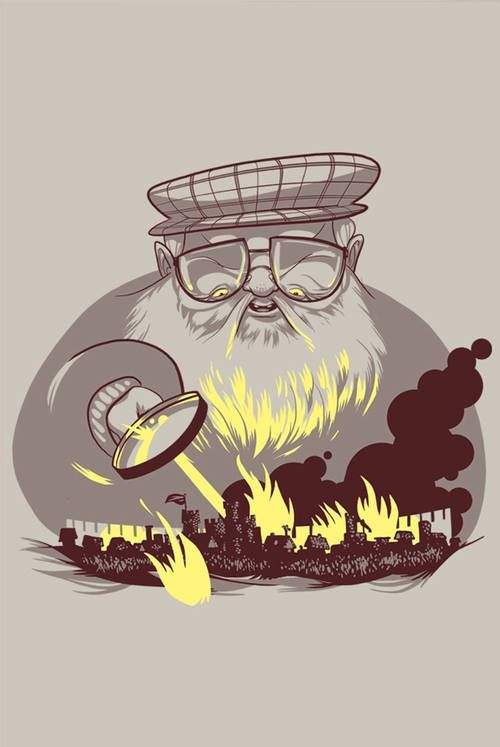

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 65.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 25.6MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [ ]:
data = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')
data_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')


**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [ ]:
data.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


In [ ]:
numeric_columns = ['dateOfBirth', 'age']
for column in numeric_columns:
    if data[column].isna().sum() > 0:
        data[column].fillna(data[column].median(), inplace=True)
    if data_test[column].isna().sum() > 0:
        data_test[column].fillna(data_test[column].median(), inplace=True)


<ipython-input-6-92ea4c61235e>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].median(), inplace=True)
<ipython-input-6-92ea4c61235e>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
categorical_columns = ['title', 'culture', 'house', 'spouse']
for column in categorical_columns:
    if data[column].isna().sum() > 0:
        data[column].fillna('Unknown', inplace=True)
    if data_test[column].isna().sum() > 0:
        data_test[column].fillna('Unknown', inplace=True)
print(data[categorical_columns].isna().sum())
print(data_test[categorical_columns].isna().sum())


title      0
culture    0
house      0
spouse     0
dtype: int64
title      0
culture    0
house      0
spouse     0
dtype: int64


<ipython-input-7-d0e366bcd94d>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna('Unknown', inplace=True)
<ipython-input-7-d0e366bcd94d>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
bool_columns = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble']
for column in bool_columns:
    if data[column].isna().sum() > 0:
        data[column].fillna(False, inplace=True)
    if data_test[column].isna().sum() > 0:
        data_test[column].fillna(False, inplace=True)
print(data[bool_columns].isna().sum())
print(data_test[bool_columns].isna().sum())


isAliveMother    0
isAliveFather    0
isAliveHeir      0
isAliveSpouse    0
isMarried        0
isNoble          0
dtype: int64
isAliveMother    0
isAliveFather    0
isAliveHeir      0
isAliveSpouse    0
isMarried        0
isNoble          0
dtype: int64


<ipython-input-8-a8aefefdb9ad>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(False, inplace=True)
<ipython-input-8-a8aefefdb9ad>:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data[column].fillna(False, inplace=True)
<ipython-input-8-a8aefefdb9ad>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Seri

In [ ]:
data['has_mother'] = data['mother'].notna().astype(int)
data['has_father'] = data['father'].notna().astype(int)
data['has_heir'] = data['heir'].notna().astype(int)
data['has_spouse'] = data['spouse'].notna().astype(int)

data_test['has_mother'] = data_test['mother'].notna().astype(int)
data_test['has_father'] = data_test['father'].notna().astype(int)
data_test['has_heir'] = data_test['heir'].notna().astype(int)
data_test['has_spouse'] = data_test['spouse'].notna().astype(int)



nan_summary_after = data_test.isna().sum()
print("Количество NaN значений после обработки:")
print(nan_summary_after)
data_test

Количество NaN значений после обработки:
name                  0
title                 0
male                  0
culture               0
dateOfBirth           0
mother              386
father              385
heir                387
house                 0
spouse                0
book1                 0
book2                 0
book3                 0
book4                 0
book5                 0
isAliveMother         0
isAliveFather         0
isAliveHeir           0
isAliveSpouse         0
isMarried             0
isNoble               0
age                   0
numDeadRelations      0
popularity            0
has_mother            0
has_father            0
has_heir              0
has_spouse            0
dtype: int64


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,has_mother,has_father,has_heir,has_spouse
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,Unknown,0,Unknown,156.0,NaN,NaN,NaN,House Blackwood,Unknown,...,False,0,0,100.0,0,0.050167,0,0,0,1
1559,Melisandre,Unknown,0,Asshai,267.0,NaN,NaN,NaN,R'hllor,Unknown,...,False,0,0,32.0,0,0.745819,0,0,0,1
1560,Merrit,Unknown,0,Unknown,267.0,NaN,NaN,NaN,Brotherhood without banners,Unknown,...,False,0,0,32.0,0,0.010033,0,0,0,1
1561,Meryn Trant,Ser,1,Unknown,267.0,NaN,NaN,NaN,House Trant,Unknown,...,False,0,1,32.0,0,0.220736,0,0,0,1
1562,Merrett Frey,Unknown,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,1.0,1,0,38.0,0,0.434783,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,Luwin,Unknown,1,Westeros,267.0,NaN,NaN,NaN,House Stark,Unknown,...,False,0,0,32.0,0,0.351171,0,0,0,1
1943,Reek,Unknown,1,Unknown,267.0,NaN,NaN,NaN,House Bolton,Unknown,...,False,0,0,32.0,0,0.096990,0,0,0,1
1944,Symeon Star-Eyes,Unknown,1,Unknown,267.0,NaN,NaN,NaN,Unknown,Unknown,...,False,0,0,32.0,0,0.030100,0,0,0,1


In [ ]:
data = data.drop(columns=['mother', 'father', 'heir', 'spouse'])
data_test = data_test.drop(columns=['mother', 'father', 'heir', 'spouse'])


**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [ ]:
data['isPopular'] = (data['popularity'] > 0.5).astype(int)
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

data_test['isPopular'] = (data_test['popularity'] > 0.5).astype(int)
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)


In [ ]:
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari', 'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
}


In [ ]:
for target, variants in cult.items():
  for variant in variants:
    data['culture'] = data['culture'].replace(variants, target)
    data_test['culture'] = data_test['culture'].replace(variants, target)




**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [ ]:
data.drop(columns=['name', 'title', 'popularity'], inplace = True)
data_test.drop(columns=['name', 'title', 'popularity'], inplace = True)


**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

isAlive
1    1212
0     345
Name: count, dtype: int64


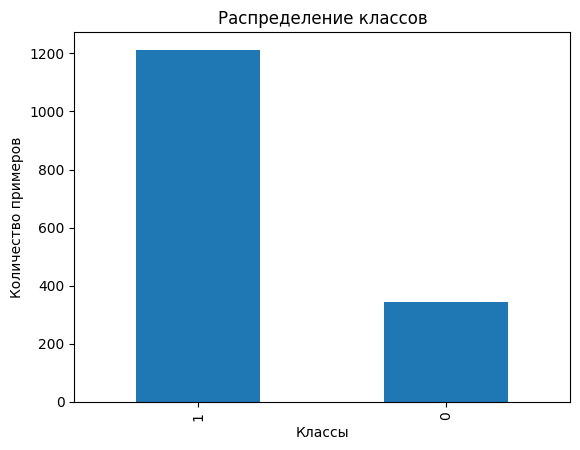

In [ ]:
target_column = 'isAlive'
class_counts = data[target_column].value_counts()
print(class_counts)


import matplotlib.pyplot as plt

class_counts.plot(kind='bar', title='Распределение классов')
plt.xlabel('Классы')
plt.ylabel('Количество примеров')
plt.show()
#целевая прееменная - категориальная

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [ ]:

categorical_columns = ['male', 'culture', 'house', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'isAlive', 'isPopular', 'boolDeadRelations' ]
categorical_features = data[categorical_columns]
categorical_features.columns
data_test

,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,isAliveMother,...,isMarried,isNoble,age,numDeadRelations,has_mother,has_father,has_heir,has_spouse,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,Unknown,156.0,House Blackwood,0,0,0,0,1,False,...,0,0,100.0,0,0,0,0,1,0,0
1559,0,Asshai,267.0,R'hllor,0,1,1,1,1,False,...,0,0,32.0,0,0,0,0,1,1,0
1560,0,Unknown,267.0,Brotherhood without banners,0,0,1,1,0,False,...,0,0,32.0,0,0,0,0,1,0,0
1561,1,Unknown,267.0,House Trant,1,1,1,1,1,False,...,0,1,32.0,0,0,0,0,1,0,0
1562,1,Riverlands,262.0,House Frey,1,1,1,1,1,False,...,1,0,38.0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,1,Westeros,267.0,House Stark,1,1,1,1,1,False,...,0,0,32.0,0,0,0,0,1,0,0
1943,1,Unknown,267.0,House Bolton,0,1,0,1,1,False,...,0,0,32.0,0,0,0,0,1,0,0
1944,1,Unknown,267.0,Unknown,1,1,1,1,1,False,...,0,0,32.0,0,0,0,0,1,0,0


In [ ]:
import numpy as np
unique_count = data['culture'].nunique()
unique_count


52

In [ ]:
data_full = pd.concat([data, data_test], axis=0)
oho = OneHotEncoder(sparse_output=False)
oho.fit(data_full[['culture', 'house']])
data.reset_index(drop = True, inplace = True)
encoded_data = oho.transform(data[['culture', 'house']])
encoded_feature_names = oho.get_feature_names_out()
encoded_frame = pd.DataFrame(encoded_data, columns=encoded_feature_names)
frame_encoded = pd.concat([data, encoded_frame], axis=1)
frame_encoded.drop(columns=['culture', 'house'], inplace = True)

index = data_test.index
data_test.reset_index(drop = True, inplace = True)
encoded_data_test = oho.transform(data_test[['culture', 'house']])
encoded_frame_test = pd.DataFrame(encoded_data_test, columns=encoded_feature_names)
frame_encoded_test = pd.concat([data_test, encoded_frame_test], axis=1)
frame_encoded_test.drop(columns=['culture', 'house'], inplace = True)
frame_encoded_test




,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,...,house_Thenn,house_Thirteen,house_Three-eyed crow,house_Undying Ones,house_Unknown,house_Unsullied,house_Windblown,house_Wise Masters,house_brotherhood without banners,house_wildling
0,0,156.0,0,0,0,0,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,267.0,0,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,267.0,0,0,1,1,0,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,267.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,262.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,1,267.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
385,1,267.0,0,1,0,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
386,1,267.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
387,1,267.0,0,0,1,1,1,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.


In [ ]:
data['isAlive'].value_counts()

,count
isAlive,
1,1212
0,345


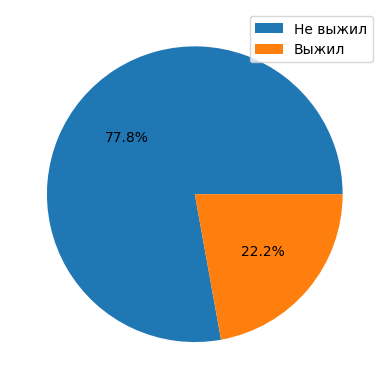

In [ ]:

graphic = data['isAlive'].value_counts()


plt.pie(graphic, autopct='%1.1f%%')

plt.legend(['Не выжил', 'Выжил'])

plt.show()

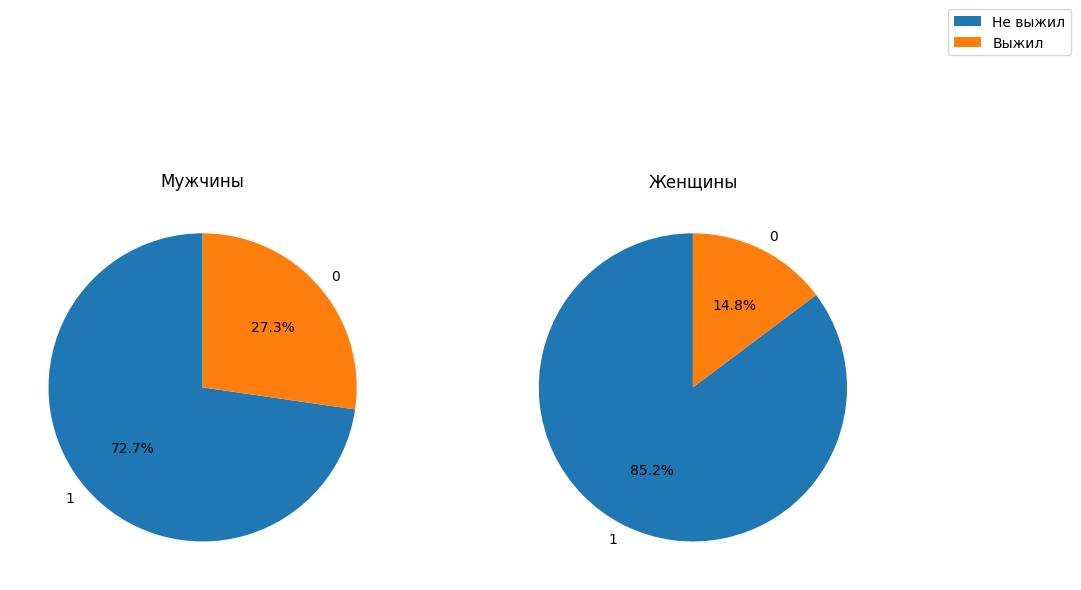

In [ ]:

data_male_survived = data[data['male'] == 1]['isAlive'].value_counts()
data_female_survived = data[data['male'] == 0]['isAlive'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(data_male_survived.values, labels=data_male_survived.index, autopct='%1.1f%%', startangle=90)
ax1.set_title("Мужчины")

ax2.pie(data_female_survived.values, labels=data_female_survived.index, autopct='%1.1f%%', startangle=90)
ax2.set_title("Женщины")

plt.legend(['Не выжил', 'Выжил'], loc='upper right', bbox_to_anchor=(1.5, 1.5))

plt.tight_layout()
plt.show()


**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
X = frame_encoded.drop(columns=['isAlive']).values
y = frame_encoded['isAlive'].values





**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
len(X_train)
X_train.shape[1]

434

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Шаг 1. Создание модели
logistic_regression = LogisticRegression(C=1, max_iter=1000, random_state=42)

# Шаг 2. Обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
svc_model = SVC(class_weight='balanced', probability=True, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
decision_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
gnb_model = GaussianNB()
ada_boost = AdaBoostClassifier(random_state=42)

random_forest.fit(X_train, y_train)
svc_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
gnb_model.fit(X_train, y_train)
ada_boost.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)
y_pred_rf = random_forest.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_gnb = gnb_model.predict(X_test)
y_pred_ada = ada_boost.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
accuracy_ada = accuracy_score(y_test, y_pred_ada)

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
y_pred = logistic_regression.predict(X_test)
y_pred = random_forest.predict(X_test)
y_pred_svc = svc_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_gnb = gnb_model.predict(X_test)
y_pred_ada = ada_boost.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
accuracy_ada = accuracy_score(y_test, y_pred_ada)

print("Accuracy : %.4f" % accuracy, accuracy_rf, accuracy_svc, accuracy_knn, accuracy_dt, accuracy_gnb, accuracy_ada)

Accuracy : 0.7981 0.7980769230769231 0.8397435897435898 0.8237179487179487 0.7596153846153846 0.3782051282051282 0.8397435897435898


Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [ ]:
y_pred_test = knn_model.predict(frame_encoded_test)
y_pred_test
#лучшая модоль - KNN

NameError: name 'knn_model' is not defined

Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.7MB/s]


In [ ]:
submission = pd.DataFrame(y_pred_test, columns=['isAlive'], index=index).reset_index()
submission


NameError: name 'y_pred_test' is not defined

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)

In [ ]:

submission1 = pd.read_csv("/content/new_submission.csv")
submission.to_csv("/content/new_submission.csv", index=False)


In [ ]:
frame_encoded_test

Как сохранить измененный Pandas DataFrame в csv файл: